## Import necessary library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap

## Get File path and load the csv data

In [2]:
from util.data_path import cassava_price_avg
from util.data_path import corn_price_avg
from util.data_path import green_bean_price_avg
from util.data_path import soybean_price_avg

In [3]:
def process_csv(data_file):
    wide = pd.read_csv(data_file)
    long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
        ["year", "month"]
    )

    long["date"] = pd.to_datetime(
        (long["year"] - 543).astype(str)
        + "-"
        + long["month"].astype(str).str.zfill(2)
        + "-01"
    )
    long = long.set_index("date").sort_index()
    return long


# Process each crop data
cassava_df = process_csv(cassava_price_avg)
corn_df = process_csv(corn_price_avg)
green_bean_df = process_csv(green_bean_price_avg)
soybean_df = process_csv(soybean_price_avg)

# Add crop name column to each dataframe
cassava_df["crop"] = "cassava"
corn_df["crop"] = "corn"
green_bean_df["crop"] = "green_bean"
soybean_df["crop"] = "soybean"

# Create a combined dataframe for all crops
all_crops_df = pd.concat([cassava_df, corn_df, green_bean_df, soybean_df])

In [4]:
normalized_df = all_crops_df.copy()

yearly_avg = all_crops_df.groupby(["crop", "year"])["price"].mean().reset_index()
yearly_avg.rename(columns={"price": "yearly_avg_price"}, inplace=True)

normalized_df = pd.merge(normalized_df, yearly_avg, on=["crop", "year"])
normalized_df["normalized_price"] = (
    normalized_df["price"] / normalized_df["yearly_avg_price"]
)

# Create a more structured result dataframe
result_df = normalized_df[
    ["year", "month", "crop", "price", "yearly_avg_price", "normalized_price"]
]
result_df = result_df.sort_values(["crop", "year", "month"])

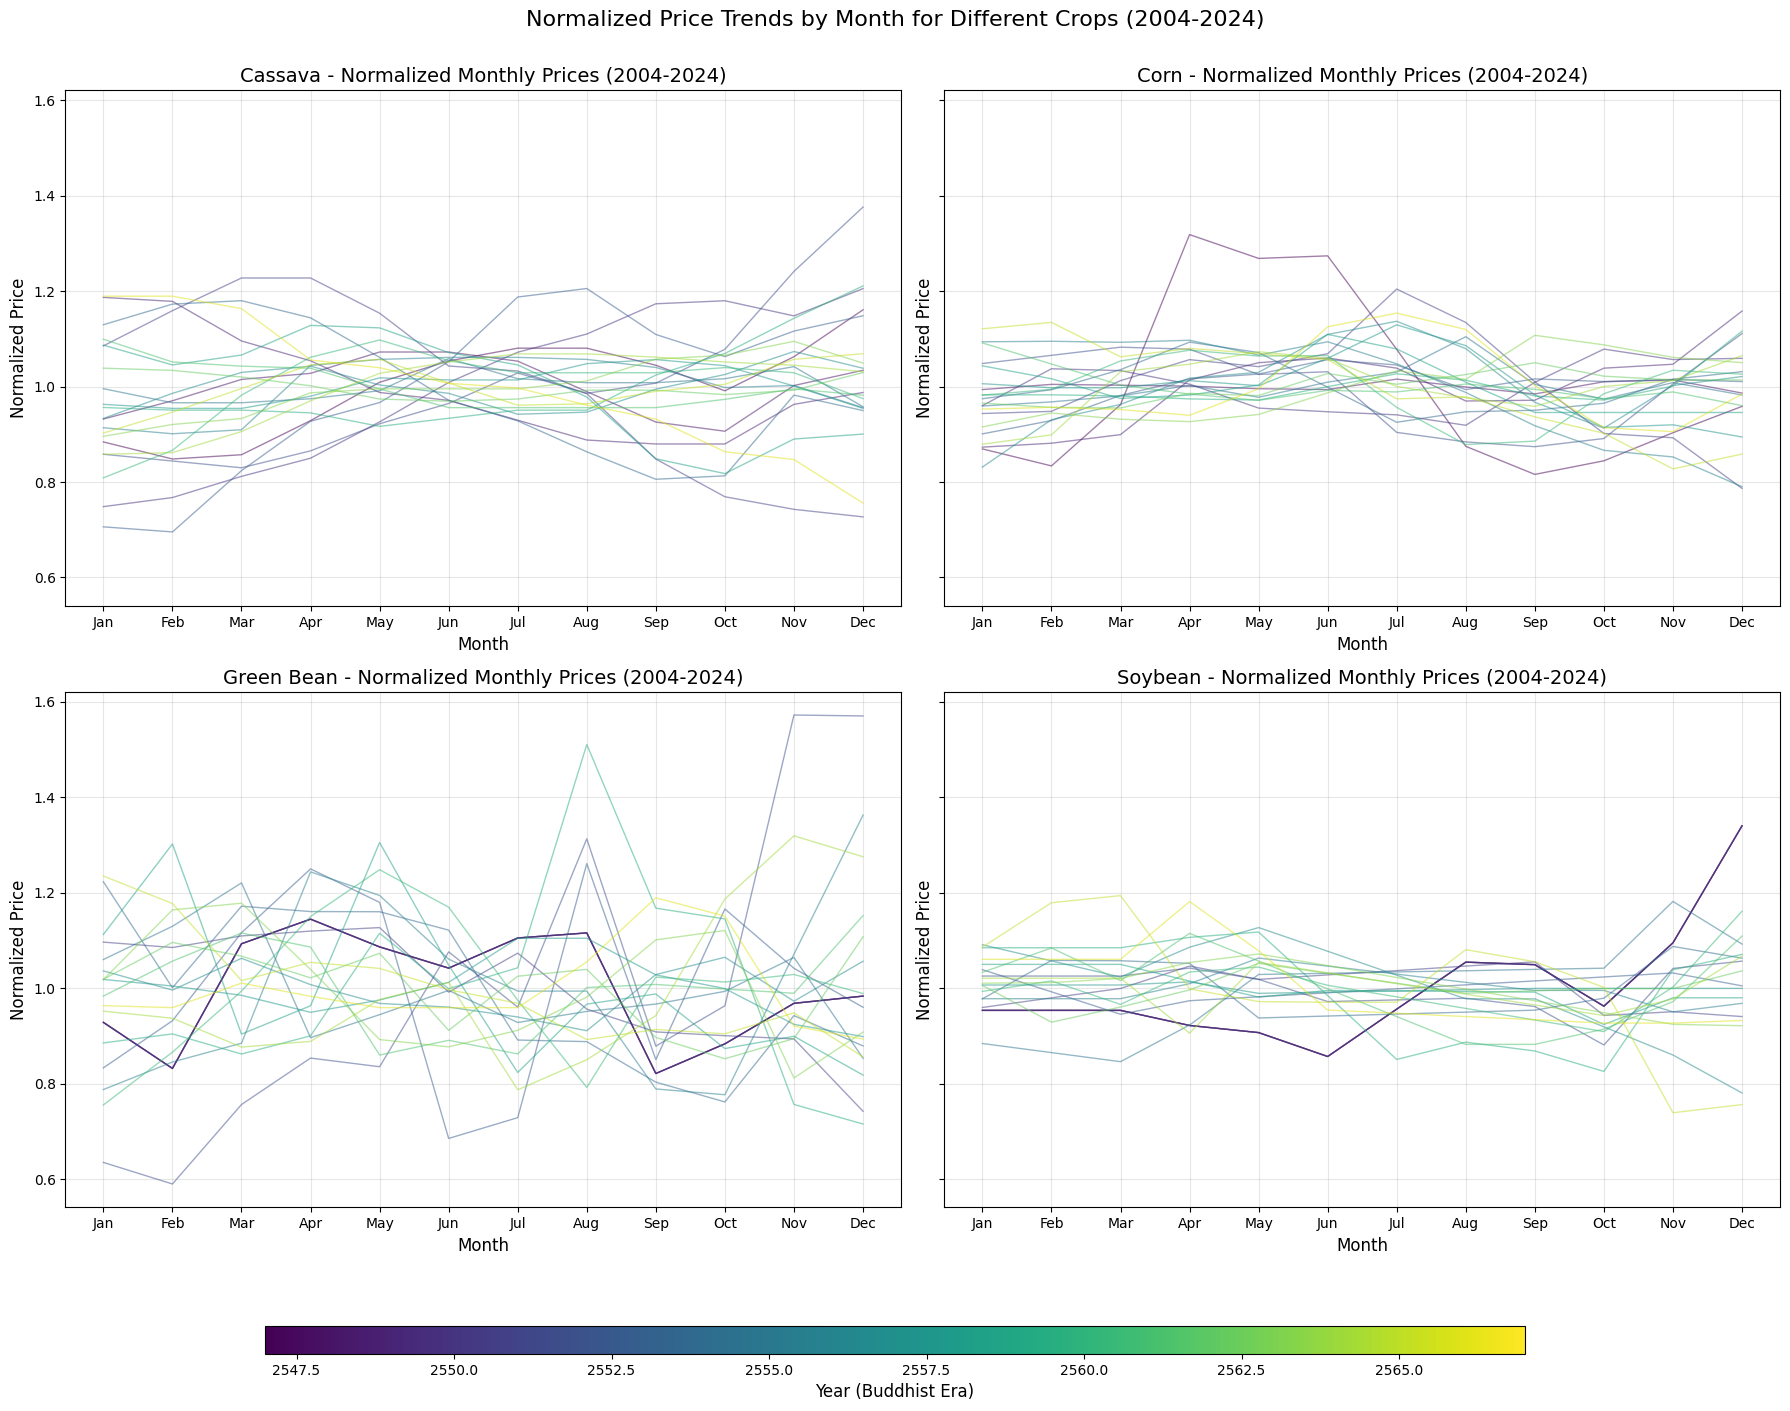

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

# Define a colormap for the years
years = sorted(result_df["year"].unique())
colormap = plt.cm.viridis
colors = {year: colormap(i / len(years)) for i, year in enumerate(years)}

# Create a list of crops
crops = ["cassava", "corn", "green_bean", "soybean"]
titles = ["Cassava", "Corn", "Green Bean", "Soybean"]

# Plot each crop on its own subplot
for i, (crop, title) in enumerate(zip(crops, titles)):
    crop_data = result_df[result_df["crop"] == crop]

    # Plot each year's data
    for year in years:
        year_data = crop_data[crop_data["year"] == year]
        year_data = year_data.copy()

        year_data["month_num"] = pd.to_numeric(year_data["month"])
        year_data = year_data.sort_values("month_num")

        axes[i].plot(
            year_data["month_num"],
            year_data["normalized_price"],
            color=colors[year],
            alpha=0.5,
            linewidth=1,
        )

    axes[i].set_title(f"{title} - Normalized Monthly Prices (2004-2024)", fontsize=14)
    axes[i].set_xlabel("Month", fontsize=12)
    axes[i].set_ylabel("Normalized Price", fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    axes[i].grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(min(years), max(years)))
sm.set_array([])

# Adjust layout first to properly position the plots
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Add colorbar at the bottom with more padding and lower position
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Year (Buddhist Era)", fontsize=12)

# Add the title with adjusted y position
plt.suptitle(
    "Normalized Price Trends by Month for Different Crops (2004-2024)",
    fontsize=16,
    y=0.98,
)

plt.show()

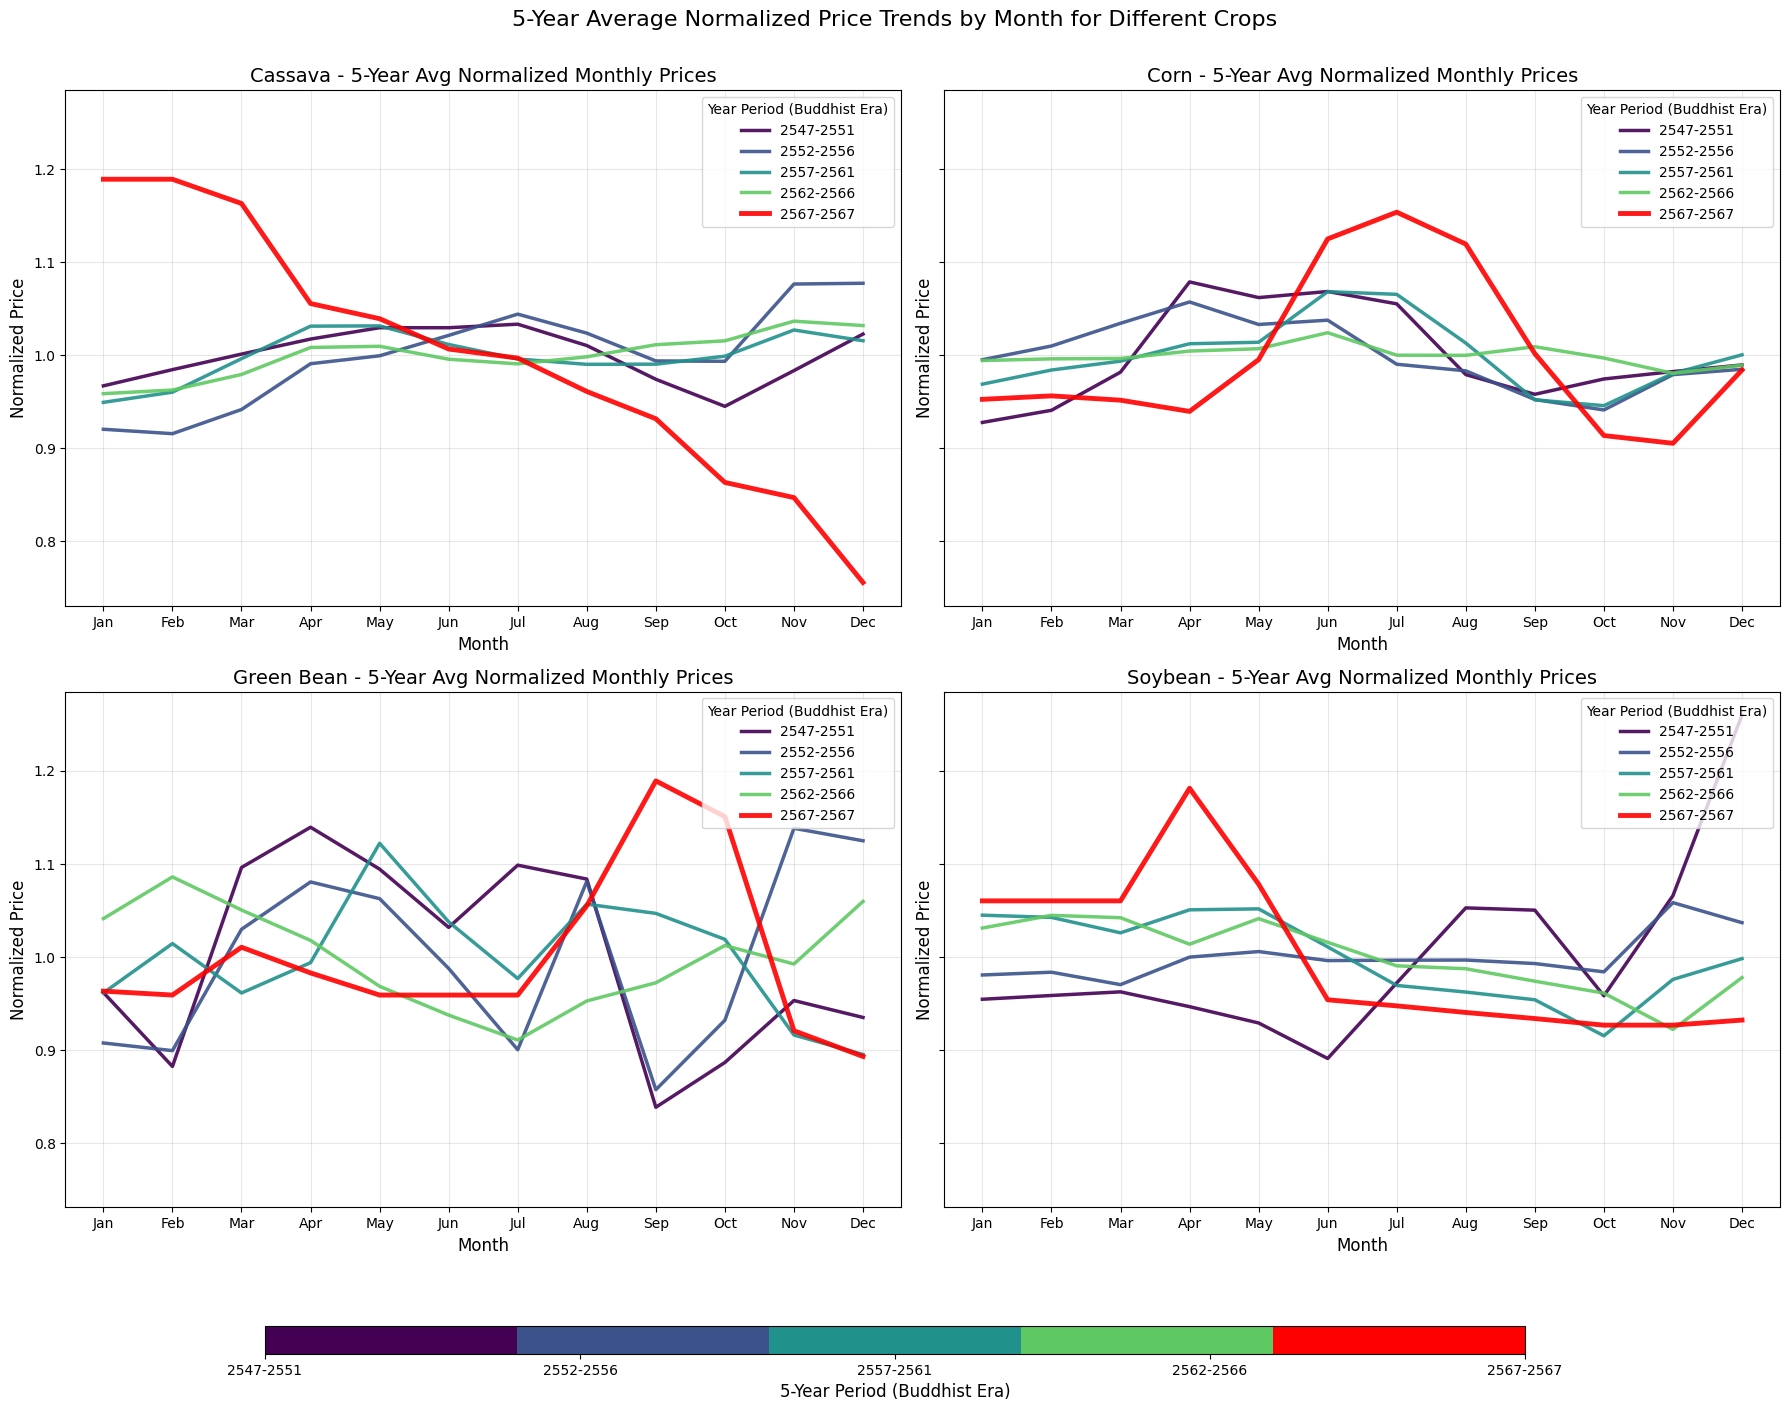

In [6]:
# Define 5-year periods
# Get the min and max years from the data
min_year = result_df["year"].min()
max_year = result_df["year"].max()

# Create period ranges that cover all available years
periods = []
current_year = min_year
while current_year <= max_year:
    end_year = min(current_year + 4, max_year)
    periods.append((current_year, end_year))
    current_year = end_year + 1

# Create a period label for each year
result_df["period"] = result_df["year"].apply(
    lambda y: next((f"{p[0]}-{p[1]}" for p in periods if p[0] <= y <= p[1]), "Unknown")
)

# Calculate the average normalized price by month for each crop and period
period_avg = (
    result_df.groupby(["crop", "period", "month"])["normalized_price"]
    .mean()
    .reset_index()
)

# Sort the periods chronologically
period_avg["period_start"] = period_avg["period"].apply(lambda p: int(p.split("-")[0]))
period_avg = period_avg.sort_values(["crop", "period_start", "month"])

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

# Define a colormap for the periods
unique_periods = sorted(
    period_avg["period"].unique(), key=lambda p: int(p.split("-")[0])
)
colormap = plt.cm.viridis

# Create custom colors dictionary - using red for the period containing year 2567
colors = {}
for i, period in enumerate(unique_periods):
    # Check if this period contains year 2567
    if "2567" in period:
        colors[period] = "red"  # Set to red
    else:
        colors[period] = colormap(
            i / (len(unique_periods) - 1)
        )  # Use colormap for others

# Create a list of crops
crops = ["cassava", "corn", "green_bean", "soybean"]
titles = ["Cassava", "Corn", "Green Bean", "Soybean"]

# Plot each crop on its own subplot
for i, (crop, title) in enumerate(zip(crops, titles)):
    crop_data = period_avg[period_avg["crop"] == crop]

    # Plot each period's average data
    for period in unique_periods:
        period_data = crop_data[crop_data["period"] == period]
        period_data = period_data.copy()

        period_data["month_num"] = pd.to_numeric(period_data["month"])
        period_data = period_data.sort_values("month_num")

        # Use thicker line for the period with 2567
        line_width = 3.5 if "2567" in period else 2.5

        axes[i].plot(
            period_data["month_num"],
            period_data["normalized_price"],
            color=colors[period],
            alpha=0.9,
            linewidth=line_width,
            label=period,
        )

    # Add labels and formatting
    axes[i].set_title(f"{title} - 5-Year Avg Normalized Monthly Prices", fontsize=14)
    axes[i].set_xlabel("Month", fontsize=12)
    axes[i].set_ylabel("Normalized Price", fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(title="Year Period (Buddhist Era)", loc="upper right")

# Create a special colormap for the colorbar that includes red for 2567


# Create colors array for the colorbar
num_periods = len(unique_periods)
color_array = np.zeros((num_periods, 4))  # RGBA

# Fill with colormap colors
for i in range(num_periods - 1):
    color_array[i] = colormap(i / (num_periods - 1))

# Set the last period (2567) to red
color_array[-1] = np.array([1, 0, 0, 1])  # Red in RGBA

custom_cmap = ListedColormap(color_array)

# Create colorbar
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=plt.Normalize(0, len(unique_periods) - 1)
)
sm.set_array([])

# Adjust layout first to properly position the plots
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Add colorbar at the bottom with more padding and lower position
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
ticks = range(len(unique_periods))
tick_labels = unique_periods
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)
cbar.set_label("5-Year Period (Buddhist Era)", fontsize=12)

# Add the title with adjusted y position
plt.suptitle(
    "5-Year Average Normalized Price Trends by Month for Different Crops",
    fontsize=16,
    y=0.98,
)

plt.show()